# Calculate OHC in surface mixed layer for 3 pts

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:35691")
client

<Client: 'tcp://127.0.0.1:35691' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

In [7]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### Calculate potential density

In [8]:
# Convert depth (m) to pressure (dbar)
p = gsw.p_from_z(HH_grid.Z, 70)  # Depth is negative

# Convert Practical Salinity (SP) to Absolute Salinity (SA)
SA = gsw.SA_from_SP(SALT_zarr_day.SALT, p, SALT_zarr_day.XC, SALT_zarr_day.YC)  # Assume longitude = 0 if unknown

# Convert Potential Temperature to Conservative Temperature
CT = gsw.conversions.CT_from_pt(SA, THETA_zarr_day.THETA)

# Calculate potential density anomaly referenced to 0 dbar (1000 is subtracted)
sigma0 = gsw.sigma0(SA, CT)

In [9]:
sigma0.name = 'potential_density'
sigma0.attrs['long_name'] = 'potential_density'

### Calculate OHC in ML

In [10]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
        salinity (array): salinity (PSU)
        temperature (array): temperature (°C)
        depth (array): depth values (m, negative downward)
        lon (float): longitude for SA calculation
        lat (float): latitude for pressure calculation
    
    Returns:
        cp (array): Specific heat capacity (J/kg/deg K) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp) in J/(kg K)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [11]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) for a time series of a profile at k=90.
    
    Parameters:
    sigma0_array (xarray.DataArray): Potential density dataset with dimensions (time, k).
    density_threshold (float): Density increase threshold to define the MLD (default = 0.03 kg/m^3).
    
    Returns:
    xarray.DataArray: MLD time series corresponding to depth where density exceeds threshold.
    """
    
    # Select surface density
    rho_Z0 = sigma0_array.isel(k=0)
    
    # Compute threshold density
    threshold = (rho_Z0 + density_threshold)
    
    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_array - threshold)
    
    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    
    # Extract the corresponding depth value for MLD
    MLD_array = sigma0_array.isel(k=threshold_idx.compute()).Z
    
    return MLD_array, threshold_idx

In [12]:
def calculate_ohc(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Parameters:
    ----------
    temp : xarray.DataArray (time, k)
        2D array of temperature (°C) with dimensions ['time', 'k'].
    salinity : xarray.DataArray (time, k)
        2D array of salinity (PSU) with dimensions ['time', 'k'].
    density : xarray.DataArray (time, k)
        2D array of seawater density (kg/m³) with dimensions ['time', 'k'].
    layer_thickness : xarray.DataArray (k)
        1D array representing the thickness of each vertical layer (m).
    threshold_idx : xarray.DataArray (time)
        1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    -------
    ohc : xarray.DataArray (time, XC, YC)
        3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m²).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z.values, lon=temp.XC.values, lat=temp.YC.values)

    # Given array of indices
    indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= indices
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc

In [12]:
cell_thickness = HH_grid.drF

i_west=540
j_west=250

i_plume=565
j_plume=180

i_east=660
j_east=120

In [14]:
salt_pt_west = SALT_zarr_day.SALT.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_west = THETA_zarr_day.THETA.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_west = sigma0.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01')) + 1000 # convert to pot density from potential density anomaly

In [15]:
salt_pt_plume = SALT_zarr_day.SALT.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_plume = THETA_zarr_day.THETA.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_plume = sigma0.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01')) + 1000

In [16]:
salt_pt_east = SALT_zarr_day.SALT.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_east = THETA_zarr_day.THETA.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_east = sigma0.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01')) + 1000

In [17]:
# calculate mld and the index of the mld along k coord
mld_pt_west, threshold_idx_west = calculate_mld(density_pt_west, density_threshold=0.03)
mld_pt_plume, threshold_idx_plume = calculate_mld(density_pt_plume, density_threshold=0.03)
mld_pt_east, threshold_idx_east = calculate_mld(density_pt_east, density_threshold=0.03)

In [98]:
# calculate OHC
ohc_mld_west = calculate_ohc(theta_pt_west, salt_pt_west, density_pt_west, cell_thickness, threshold_idx_west).compute()
ohc_mld_plume = calculate_ohc(theta_pt_plume, salt_pt_plume, density_pt_plume, cell_thickness, threshold_idx_plume).compute()
ohc_mld_east = calculate_ohc(theta_pt_east, salt_pt_east, density_pt_east, cell_thickness, threshold_idx_east).compute()

In [99]:
# sanity check vals
print(theta_pt_east.isel(time=0).values[0:5])
print(salt_pt_east.isel(time=0).values[0:5])
print(density_pt_east.isel(time=0).values[0:5])
print(cell_thickness.values[0:5])
print(threshold_idx_east.values[0:5])

[-1.2968384  -1.22747934 -1.21073425 -0.09678689  0.79995602]
[24.56088448 24.62095833 24.66266823 25.53451538 26.80315018]
[1019.70872509 1019.75714653 1019.79084071 1020.4798005  1021.47228557]
[1.   1.14 1.3  1.49 1.7 ]
[1 2 1 3 3]


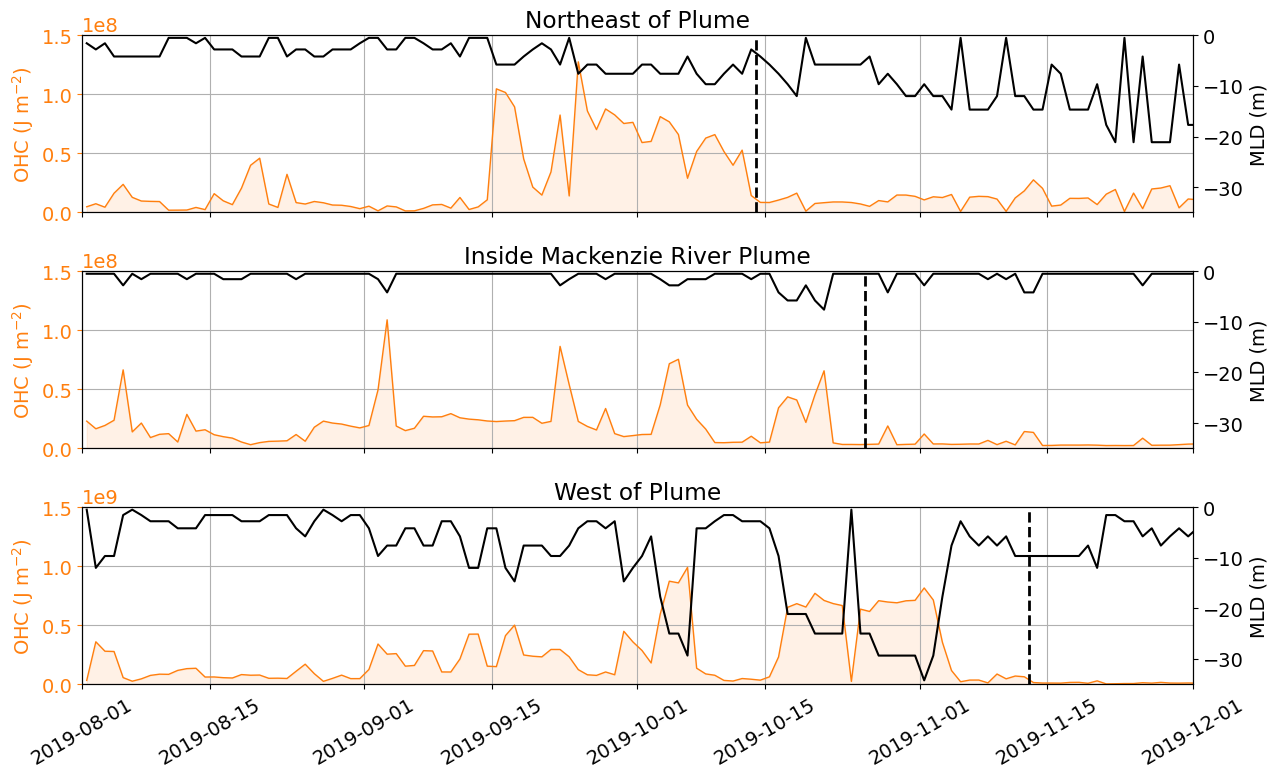

In [100]:
plt.rcParams['font.size'] = 14

# Create a figure with 3 rows, shared x-axis
fig, axes = plt.subplots(nrows=3, figsize=(13, 8), sharex=True)

# Data and titles for each subplot
ohc_data = [
    (ohc_mld_east, mld_pt_east, "Northeast of Plume"),
    (ohc_mld_plume, mld_pt_plume, "Inside Mackenzie River Plume"),
    (ohc_mld_west, mld_pt_west, "West of Plume")
]

# Plot each dataset in a loop
for ax, (ohc_mld, mld, title) in zip(axes, ohc_data):
    # Plot OHC on primary y-axis (left) using xarray's plot function
    ohc_mld.plot(ax=ax, color='tab:orange', linewidth=1, label="OHC")

    # Shade area below the orange line
    ax.fill_between(ohc_mld.time, ohc_mld, color='tab:orange', alpha=0.1)

    ax.set_ylabel("OHC (J m$^{-2}$)", color='tab:orange')  # Set y-label color
    ax.tick_params(axis='y', colors='tab:orange')  # Set tick color

    # Create secondary y-axis for MLD
    ax2 = ax.twinx()
    mld.plot(ax=ax2, color='k', linewidth=1.5, linestyle='solid', label="MLD")
    ax2.set_ylabel("MLD (m)", color='k')

    # Set secondary y-axis limits
    ax2.set_ylim(-35, 0)

    # Formatting
    ax.set_title("")
    ax2.set_title("")
    ax.set_xlabel("")
    ax2.set_xlabel("")
    ax.set_title(title)
    ax.grid()

# Set shared x-label
axes[0].set_ylim(0, 1.5e8)
axes[1].set_ylim(0, 1.5e8)
axes[2].set_ylim(0, 1.5e9)

# add day when si>15%
axes[0].axvline(x=np.datetime64('2019-10-14'), linestyle='dashed', linewidth=2, color='k')
axes[1].axvline(x=np.datetime64('2019-10-26'), linestyle='dashed', linewidth=2, color='k')
axes[2].axvline(x=np.datetime64('2019-11-13'), linestyle='dashed', linewidth=2, color='k')

# Set x-axis limits based on dataset min/max
min_time = np.datetime64('2019-08-01')
max_time = np.datetime64('2019-12-01')
axes[-1].set_xlim(min_time, max_time)

# Improve x-axis date formatting on the last axis
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

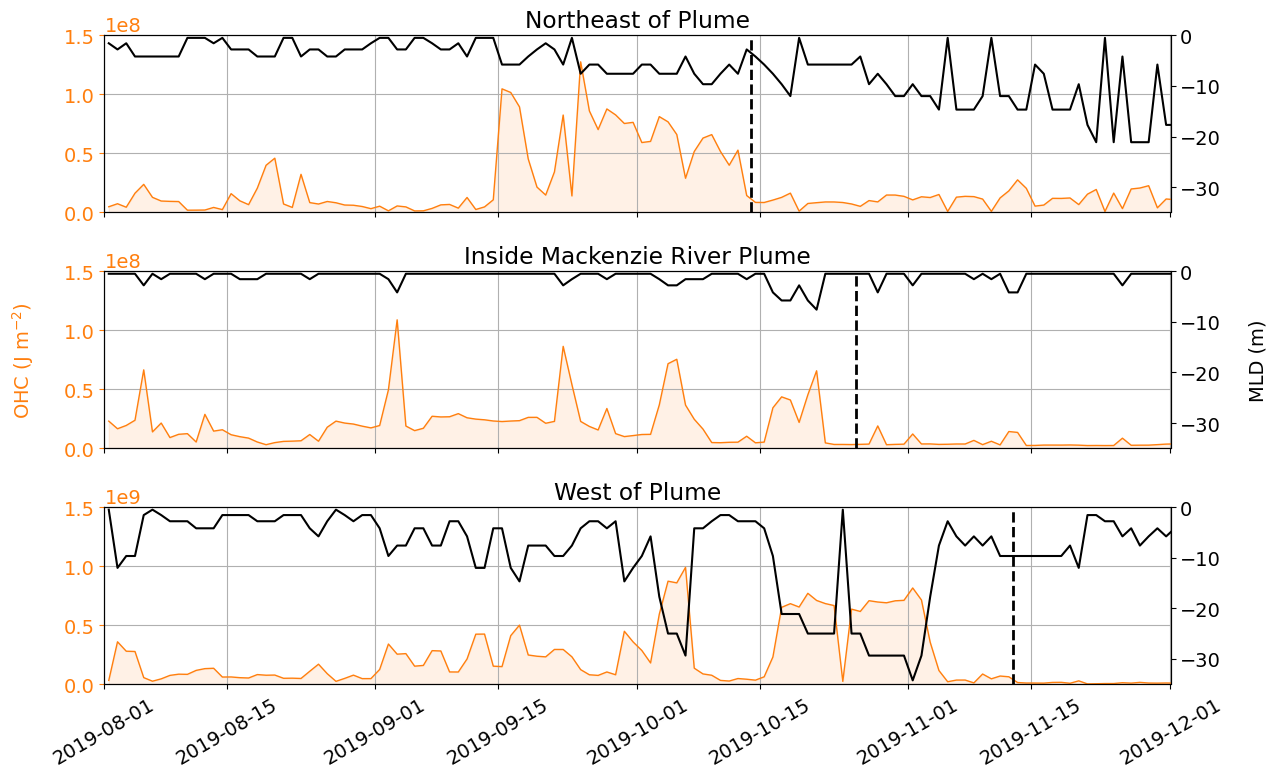

In [104]:
plt.rcParams['font.size'] = 14

# Create a figure with 3 rows, shared x-axis
fig, axes = plt.subplots(nrows=3, figsize=(13, 8), sharex=True)

# Data and titles for each subplot
ohc_data = [
    (ohc_mld_east, mld_pt_east, "Northeast of Plume"),
    (ohc_mld_plume, mld_pt_plume, "Inside Mackenzie River Plume"),
    (ohc_mld_west, mld_pt_west, "West of Plume")
]

# Plot each dataset in a loop
for i, (ax, (ohc_mld, mld, title)) in enumerate(zip(axes, ohc_data)):
    # Plot OHC on primary y-axis (left)
    ohc_mld.plot(ax=ax, color='tab:orange', linewidth=1, label="OHC")

    # Shade area below the orange line
    ax.fill_between(ohc_mld.time, ohc_mld, color='tab:orange', alpha=0.1)

    # Create secondary y-axis for MLD
    ax2 = ax.twinx()
    mld.plot(ax=ax2, color='k', linewidth=1.5, linestyle='solid', label="MLD")

    # Only add y-axis labels in the middle subplot
    if i == 1:
        ax.set_ylabel("OHC (J m$^{-2}$)", color='tab:orange', labelpad=20)
        ax.tick_params(axis='y', colors='tab:orange')  # Set tick labels to orange
        ax2.set_ylabel("MLD (m)", color='k', labelpad=20)
    else:
        ax.set_ylabel("")
        ax.tick_params(axis='y', colors='tab:orange')  # Still keep ticks orange
        ax2.set_ylabel("")

    # Set secondary y-axis limits
    ax2.set_ylim(-35, 0)

    # Formatting
    ax.set_title("")
    ax2.set_title("")
    ax.set_xlabel("")
    ax2.set_xlabel("")
    ax.set_title(title)
    ax.grid()

# Set shared y-axis limits
axes[0].set_ylim(0, 1.5e8)
axes[1].set_ylim(0, 1.5e8)
axes[2].set_ylim(0, 1.5e9)

# Add vertical lines for when sea ice >15%
axes[0].axvline(x=np.datetime64('2019-10-14'), linestyle='dashed', linewidth=2, color='k')
axes[1].axvline(x=np.datetime64('2019-10-26'), linestyle='dashed', linewidth=2, color='k')
axes[2].axvline(x=np.datetime64('2019-11-13'), linestyle='dashed', linewidth=2, color='k')

# Set x-axis limits
min_time = np.datetime64('2019-08-01')
max_time = np.datetime64('2019-12-01')
axes[-1].set_xlim(min_time, max_time)

# Improve x-axis date formatting on the last axis
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()


### Calculate MLD for entire time series

In [10]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) for a time series of a profile at k=90.
    
    Parameters:
    sigma0_array (xarray.DataArray): Potential density dataset with dimensions (time, k).
    density_threshold (float): Density increase threshold to define the MLD (default = 0.03 kg/m^3).
    
    Returns:
    xarray.DataArray: MLD time series corresponding to depth where density exceeds threshold.
    """
    
    # Select surface density
    rho_Z0 = sigma0_array.isel(k=0)
    
    # Compute threshold density
    threshold = (rho_Z0 + density_threshold)
    
    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_array - threshold)
    
    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    
    # Extract the corresponding depth value for MLD
    MLD_array = sigma0_array.isel(k=threshold_idx.compute()).Z
    
    return MLD_array

In [15]:
density_pt_west = sigma0.isel(i=i_west,j=j_west) + 1000 # convert to pot density from potential density anomaly
density_pt_plume = sigma0.isel(i=i_plume,j=j_plume) + 1000
density_pt_east = sigma0.isel(i=i_east,j=j_east) + 1000

In [16]:
# fill in gaps
density_pt_west = density_pt_west.chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
density_pt_plume = density_pt_plume.chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
density_pt_east = density_pt_east.chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")

In [ ]:
# calculate mld and the index of the mld along k coord
mld_pt_west = calculate_mld(density_pt_west, density_threshold=0.03).compute()
mld_pt_plume = calculate_mld(density_pt_plume, density_threshold=0.03).compute()
mld_pt_east = calculate_mld(density_pt_east, density_threshold=0.03).compute()

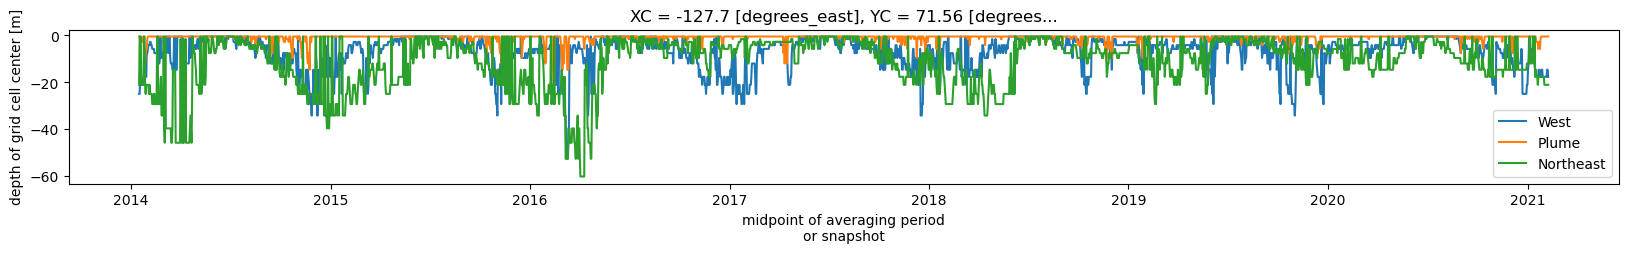

In [26]:
# Create a figure with 3 lines
fig, ax = plt.subplots(nrows=1, figsize=(20, 2), sharex=True)

mld_pt_west.plot(ax=ax,color='tab:blue',label='West')
mld_pt_plume.plot(ax=ax,color='tab:orange',label='Plume')
mld_pt_east.plot(ax=ax,color='tab:green',label='Northeast')

plt.legend();

### Calculate OHC in ML

In [13]:
density_pt_west = sigma0.isel(i=i_west,j=j_west).sel(time=slice('2019-01-01','2020-12-31')) + 1000 # convert to pot density from potential density anomaly
density_pt_plume = sigma0.isel(i=i_plume,j=j_plume).sel(time=slice('2019-01-01','2020-12-31')) + 1000
density_pt_east = sigma0.isel(i=i_east,j=j_east).sel(time=slice('2019-01-01','2020-12-31')) + 1000

In [18]:
density_pt_west = sigma0.isel(i=i_west,j=j_west).sel(time=slice('2019','2020')) + 1000 # convert to pot density from potential density anomaly
density_pt_plume = sigma0.isel(i=i_plume,j=j_plume).sel(time=slice('2019','2020')) + 1000
density_pt_east = sigma0.isel(i=i_east,j=j_east).sel(time=slice('2019','2020')) + 1000

In [19]:
# calculate mld and the index of the mld along k coord
mld_pt_west = calculate_mld(density_pt_west, density_threshold=0.03).compute()
mld_pt_plume = calculate_mld(density_pt_plume, density_threshold=0.03).compute()
# mld_pt_east = calculate_mld(density_pt_east, density_threshold=0.03).compute()

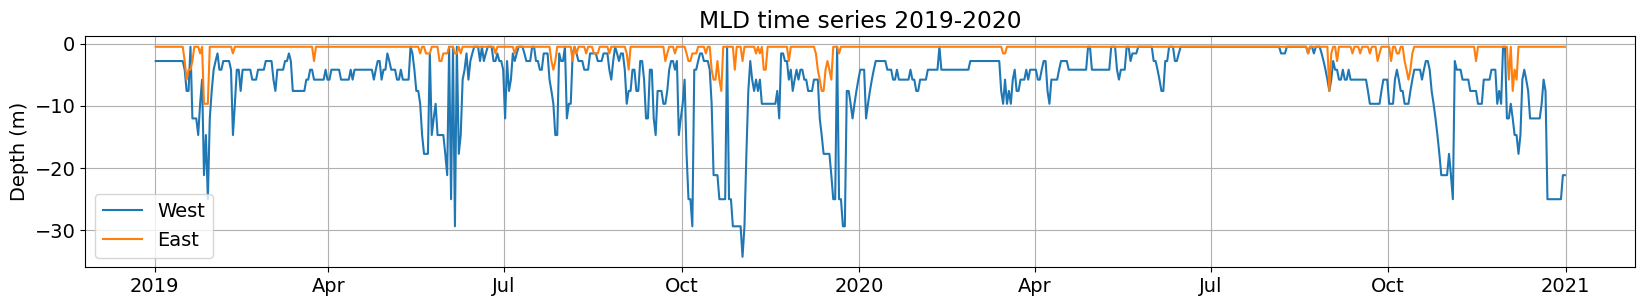

In [20]:
# Create a figure with 3 lines
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(nrows=1, figsize=(20, 3), sharex=True)

mld_pt_west.plot(ax=ax,color='tab:blue',label='West')
mld_pt_plume.plot(ax=ax,color='tab:orange',label='East')
# mld_pt_east.plot(ax=ax,color='tab:green',label='Northeast')

plt.title('MLD time series 2019-2020')
plt.grid()
plt.ylabel('Depth (m)')
plt.xlabel("")
plt.legend();